# DATE2 实验 1：MoE/非 MoE 瓶颈与时变访存流

数据源：
- `outputs/DATE2/exp1/layer_characterization.csv`

本 Notebook 对应论文 B1 与 C1，回答三个问题：

1. MoE Expert FF1/FF2 是否贡献主要 memory stall？
2. Stall ratio 是否与 Bank imbalance/conflict 同步变化？
3. 不同专家、FFN 阶段的 IA/Weight/OA 需求及理想 Bank 比例是否变化？

注意：“访存瓶颈集中于MoE”表示MoE贡献了不成比例的暴露访存停顿，
并不要求每个MoE层的访存停顿绝对值大于其计算周期。


In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

roots=[Path.cwd().resolve(),Path.cwd().resolve().parent]
ROOT=next(path for path in roots if (path/'outputs/DATE2/exp1/layer_characterization.csv').exists())
DATA=ROOT/'outputs/DATE2/exp1/layer_characterization.csv'
TEMPORAL=ROOT/'outputs/DATE2/exp1/temporal_bank_demand.csv'
FIG=ROOT/'fig/DATE2'; FIG.mkdir(parents=True,exist_ok=True)
df=pd.read_csv(DATA)
temporal=pd.read_csv(TEMPORAL)
required={'layer','layer_type','compute_cycles','memory_service_cycles',
          'operand_load_stall_cycles','output_store_stall_cycles',
          'memory_stall_cycles','stall_ratio','ia_bytes','weight_bytes',
          'accumulator_bytes','oa_bytes','accumulator_mode',
          'critical_bank_service_cycles','aggregate_bank_service_cycles',
          'memory_to_compute_ratio',
          'ia_stall_cycles','weight_stall_cycles','shared_operand_stall_cycles',
          'accumulator_stall_cycles','oa_stall_cycles',
          'pressure_weighted_bank_imbalance',
          'pressure_weighted_bank_conflict',
          'bank_conflict_rate','bank_imbalance','ideal_ia_banks',
          'ideal_weight_banks','ideal_oa_banks'}
assert required.issubset(df.columns)
assert len(df)==23 and df.layer.nunique()==23
assert set(df.accumulator_mode)=={'banked_rmw'}
assert (df.accumulator_bytes>0).all()
assert np.allclose(df.compute_cycles+df.memory_stall_cycles,df.total_cycles)
assert np.allclose(
    df[['ia_stall_cycles','weight_stall_cycles','shared_operand_stall_cycles',
        'accumulator_stall_cycles','oa_stall_cycles']].sum(axis=1),
    df.memory_stall_cycles)
assert {'tile_index','ia_working_set_bytes','weight_working_set_bytes',
        'oa_working_set_bytes','accumulator_working_set_bytes',
        'active_ia_banks','active_weight_banks','active_oa_banks'}.issubset(temporal.columns)
df['category']=df.layer_type.replace({'Expert-FF1':'MoE Expert','Expert-FF2':'MoE Expert'})
df.head()


,layer,layer_type,M,N,K,compute_cycles,mac_cycles,requant_cycles,memory_service_cycles,operand_load_stall_cycles,...,bank_conflict_rate,pressure_weighted_bank_conflict,bank_imbalance,pressure_weighted_bank_imbalance,physical_bank_busy_cv,ownership_mismatch,ideal_ia_banks,ideal_weight_banks,ideal_oa_banks,category
0,Attn_Q_proj,Non-MoE,256,96,96,10944,9216,1728,8192,2304,...,0.878735,2.189129,1.023987,2.550985,1.026546,0.133333,6,3,6,Non-MoE
1,Attn_K_proj,Non-MoE,256,96,96,10944,9216,1728,8192,2304,...,0.878735,2.189129,1.023987,2.550985,1.026546,0.133333,6,3,6,Non-MoE
2,Attn_V_proj,Non-MoE,256,96,96,10944,9216,1728,8192,2304,...,0.878735,2.189129,1.023987,2.550985,1.026546,0.133333,6,3,6,Non-MoE
3,QKT_head,Non-MoE,256,128,16,4352,2048,2304,688,512,...,0.852448,0.601728,0.642824,0.453758,0.644668,0.533333,1,1,13,Non-MoE
4,QKTV_head,Non-MoE,256,16,128,2336,2048,288,2112,512,...,0.880271,2.339351,1.081192,2.873303,1.045777,0.533333,13,1,1,Non-MoE


## 1. 计算需求与关键Bank服务需求

Tile因果模型中，`memory_stall_cycles`由IA/Weight就绪、ACC写回/RMW和OA写回
在关键路径上实际暴露的等待组成，并满足`Total = Compute + Memory stall`。
因此这里可以与计算周期直接比较。`critical_bank_service_cycles`仅作为Bank活动量诊断，
不再拿来替代端到端访存瓶颈。


In [51]:
summary=df.groupby('category').agg(
    layers=('layer','count'),
    compute_total=('compute_cycles','sum'),
    critical_bank_total=('critical_bank_service_cycles','sum'),
    stall_total=('memory_stall_cycles','sum'),
    total_cycles=('total_cycles','sum'),
    compute_mean=('compute_cycles','mean'),
    critical_bank_mean=('critical_bank_service_cycles','mean'),
    stall_mean=('memory_stall_cycles','mean'),
    stall_ratio_mean=('stall_ratio','mean'),
    conflict_rate_mean=('bank_conflict_rate','mean'),
    imbalance_mean=('bank_imbalance','mean'),
).reset_index()
summary.to_csv(FIG/'exp1_group_summary.csv',index=False)
display(summary.round(3))


,category,layers,compute_total,critical_bank_total,stall_total,total_cycles,compute_mean,critical_bank_mean,stall_mean,stall_ratio_mean,conflict_rate_mean,imbalance_mean
0,MoE Expert,16,54522,43176,145602,200124,3407.625,2698.500,9100.125,0.720,0.826,0.629
1,Non-MoE,7,51520,36336,120800,172320,7360.000,5190.857,17257.143,0.671,0.863,1.002


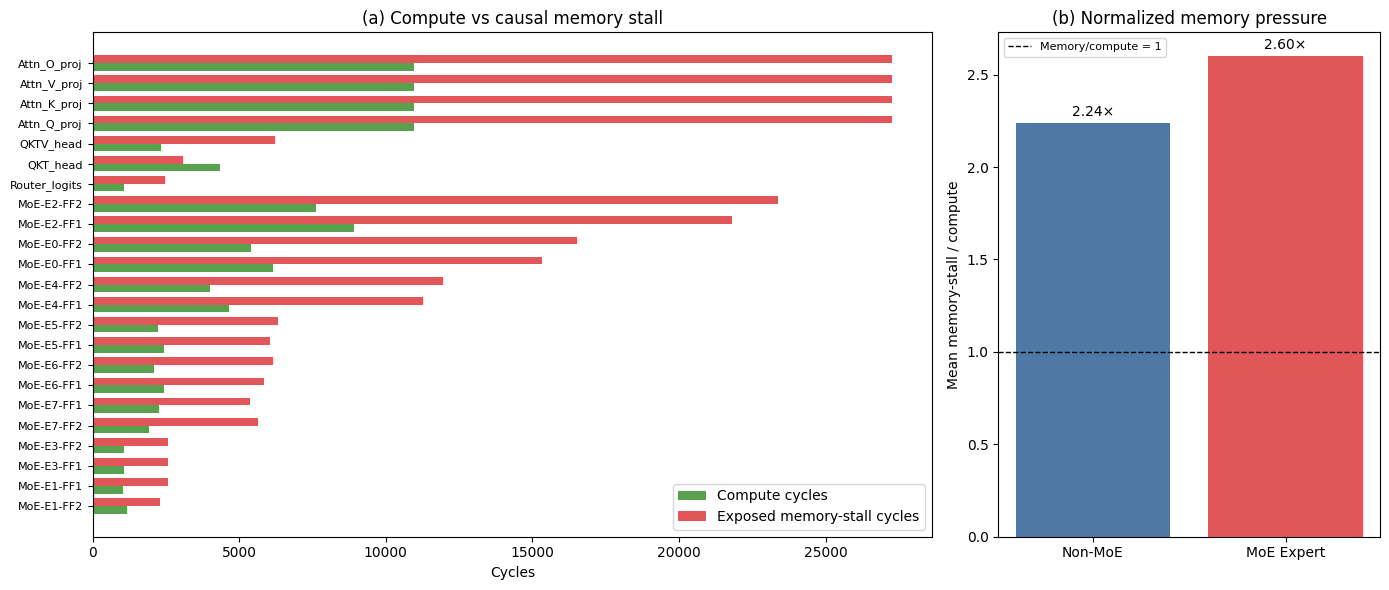

In [52]:
order=df.sort_values(['category','total_cycles']).reset_index(drop=True)
colors={'Non-MoE':'#4E79A7','MoE Expert':'#E15759'}
fig,axes=plt.subplots(1,2,figsize=(14,6),gridspec_kw={'width_ratios':[2.2,1]})
y=np.arange(len(order))
height=.38
axes[0].barh(y-height/2,order.compute_cycles,height,color='#59A14F',label='Compute cycles')
axes[0].barh(y+height/2,order.memory_stall_cycles,height,color='#E15759',label='Exposed memory-stall cycles')
axes[0].set_yticks(y,order.layer,fontsize=8); axes[0].set_xlabel('Cycles'); axes[0].set_title('(a) Compute vs causal memory stall'); axes[0].legend()
means=summary.set_index('category').loc[['Non-MoE','MoE Expert']]
x=np.arange(2)
ratio_by_category=df.groupby('category').memory_to_compute_ratio.mean().reindex(['Non-MoE','MoE Expert'])
bars=axes[1].bar(x,ratio_by_category,color=['#4E79A7','#E15759'])
axes[1].axhline(1,color='black',lw=1,ls='--',label='Memory/compute = 1')
axes[1].bar_label(bars,fmt='%.2f×',padding=3)
axes[1].set_xticks(x,['Non-MoE','MoE Expert']); axes[1].set_ylabel('Mean memory-stall / compute')
axes[1].set_title('(b) Normalized memory pressure'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'exp1_cycle_breakdown.pdf',bbox_inches='tight'); plt.show()


In [53]:
by_category=summary.set_index('category')
moe=by_category.loc['MoE Expert']; non=by_category.loc['Non-MoE']
print(f"MoE mean exposed stall: {moe.stall_mean:.1f} cycles")
print(f"Non-MoE mean exposed stall: {non.stall_mean:.1f} cycles")
print(f"MoE mean critical-Bank activity: {moe.critical_bank_mean:.1f} cycles")
print(f"Non-MoE mean critical-Bank activity: {non.critical_bank_mean:.1f} cycles")
print(f"MoE mean memory/compute ratio: {df.loc[df.category.eq('MoE Expert'),'memory_to_compute_ratio'].mean():.2f}x")
print(f"Non-MoE mean memory/compute ratio: {df.loc[df.category.eq('Non-MoE'),'memory_to_compute_ratio'].mean():.2f}x")
print(f"MoE mean stall ratio: {moe.stall_ratio_mean:.1%}")
print(f"Non-MoE mean stall ratio: {non.stall_ratio_mean:.1%}")
moe_stall_share=moe.stall_total/summary.stall_total.sum()
moe_compute_share=moe.compute_total/summary.compute_total.sum()
stall_amplification=moe.stall_mean/non.stall_mean
ratio_gap=moe.stall_ratio_mean-non.stall_ratio_mean
moe_mem_compute=df.loc[df.category.eq('MoE Expert'),'memory_to_compute_ratio'].mean()
non_mem_compute=df.loc[df.category.eq('Non-MoE'),'memory_to_compute_ratio'].mean()
print(f"MoE share of all exposed memory stall: {moe_stall_share:.1%}")
print(f"MoE share of all compute cycles: {moe_compute_share:.1%}")
print(f"Aggregate MoE/Non-MoE memory-stall ratio: {moe.stall_total/non.stall_total:.2f}x")
print(f"Mean stall-ratio gap: {ratio_gap:.1%}")
print("Disproportionate MoE memory pressure:",
      bool(moe_stall_share>moe_compute_share and
           moe_mem_compute>non_mem_compute and ratio_gap>0))
memory_bound=df.memory_to_compute_ratio>1
print(f"Memory-bound layers (exposed memory stall > compute): {memory_bound.sum()}/{len(df)}")
print(f"Memory-bound MoE layers: {(memory_bound & df.category.eq('MoE Expert')).sum()}/{df.category.eq('MoE Expert').sum()}")


MoE mean exposed stall: 9100.1 cycles
Non-MoE mean exposed stall: 17257.1 cycles
MoE mean critical-Bank activity: 2698.5 cycles
Non-MoE mean critical-Bank activity: 5190.9 cycles
MoE mean memory/compute ratio: 2.60x
Non-MoE mean memory/compute ratio: 2.24x
MoE mean stall ratio: 72.0%
Non-MoE mean stall ratio: 67.1%
MoE share of all exposed memory stall: 54.7%
MoE share of all compute cycles: 51.4%
Aggregate MoE/Non-MoE memory-stall ratio: 1.21x
Mean stall-ratio gap: 4.9%
Disproportionate MoE memory pressure: True
Memory-bound layers (exposed memory stall > compute): 22/23
Memory-bound MoE layers: 16/16


红柱高于绿柱表示因果时序中实际暴露的访存等待超过MAC与requant计算时间。


## 1.1 IA / Weight / ACC / OA Stall Breakdown


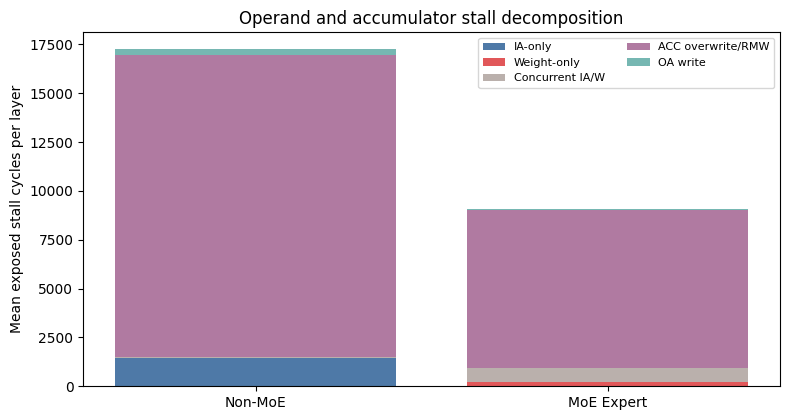

,ia_stall_cycles,weight_stall_cycles,shared_operand_stall_cycles,accumulator_stall_cycles,oa_stall_cycles
category,,,,,
Non-MoE,1424.6,0.0,93.1,15433.1,306.3
MoE Expert,27.0,171.0,720.0,8095.5,86.6


In [54]:
stall_cols=['ia_stall_cycles','weight_stall_cycles','shared_operand_stall_cycles',
            'accumulator_stall_cycles','oa_stall_cycles']
stall_labels=['IA-only','Weight-only','Concurrent IA/W','ACC overwrite/RMW','OA write']
stall_colors=['#4E79A7','#E15759','#BAB0AC','#B07AA1','#76B7B2']
q=df.groupby('category')[stall_cols].mean().reindex(['Non-MoE','MoE Expert'])
fig,ax=plt.subplots(figsize=(8,4.3));bottom=np.zeros(len(q))
for col,label,color in zip(stall_cols,stall_labels,stall_colors):
    ax.bar(q.index,q[col],bottom=bottom,label=label,color=color)
    bottom+=q[col].to_numpy()
ax.set_ylabel('Mean exposed stall cycles per layer')
ax.set_title('Operand and accumulator stall decomposition');ax.legend(ncol=2,fontsize=8)
plt.tight_layout();plt.savefig(FIG/'exp1_stall_breakdown.pdf',bbox_inches='tight');plt.show()
display(q.round(1))


## 2. Banked INT32 ACC工作集

主模型使用独立片上ACC Bank保存跨K-tile部分和。首个K-tile覆盖写，
后续K-tile通过AccPipe执行3周期原子RMW。这里观察ACC工作集与暴露停顿，
不再使用“局部ACC/假设spill”模型。


,category,accumulator_bytes_mean,memory_stall_mean,total_cycles_mean
0,MoE Expert,27456.000,9100.125,12507.750
1,Non-MoE,79579.429,17257.143,24617.143


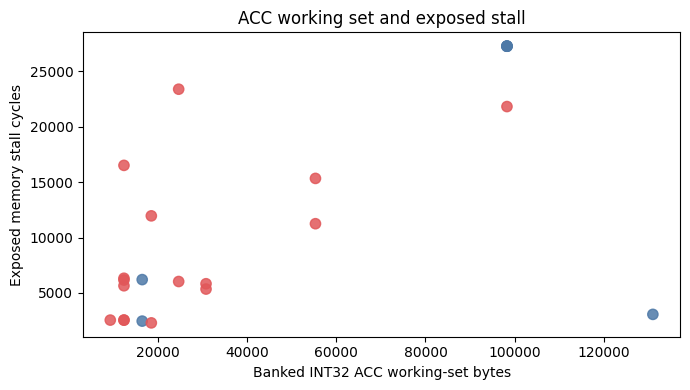

In [55]:
acc_summary=df.groupby('category').agg(
    accumulator_bytes_mean=('accumulator_bytes','mean'),
    memory_stall_mean=('memory_stall_cycles','mean'),
    total_cycles_mean=('total_cycles','mean')).reset_index()
display(acc_summary.round(3))
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(df.accumulator_bytes,df.memory_stall_cycles,
           c=df.category.map(colors),s=55,alpha=.85)
ax.set_xlabel('Banked INT32 ACC working-set bytes')
ax.set_ylabel('Exposed memory stall cycles')
ax.set_title('ACC working set and exposed stall')
plt.tight_layout();plt.savefig(FIG/'exp1_banked_acc_working_set.pdf',bbox_inches='tight');plt.show()


## 3. Stall ratio、Bank imbalance 与 conflict


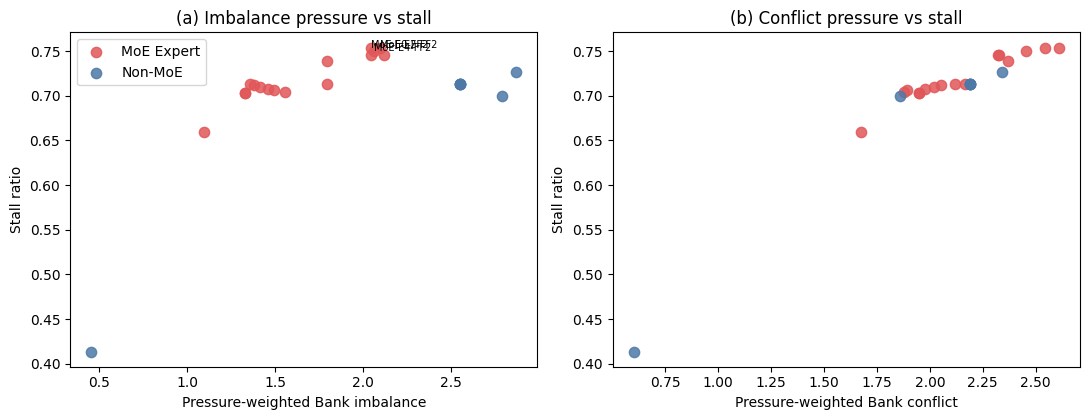

All layers correlation


,stall_ratio,bank_imbalance,bank_conflict_rate,pressure_weighted_bank_imbalance,pressure_weighted_bank_conflict
stall_ratio,1.000,0.110,-0.145,0.577,0.945
bank_imbalance,0.110,1.000,0.397,0.860,0.170
bank_conflict_rate,-0.145,0.397,1.000,0.254,0.033
pressure_weighted_bank_imbalance,0.577,0.860,0.254,1.000,0.643
pressure_weighted_bank_conflict,0.945,0.170,0.033,0.643,1.000


Expert-only correlation


,stall_ratio,bank_imbalance,bank_conflict_rate,pressure_weighted_bank_imbalance,pressure_weighted_bank_conflict
stall_ratio,1.000,0.681,-0.220,0.925,0.959
bank_imbalance,0.681,1.000,-0.227,0.898,0.646
bank_conflict_rate,-0.220,-0.227,1.000,-0.220,0.052
pressure_weighted_bank_imbalance,0.925,0.898,-0.220,1.000,0.897
pressure_weighted_bank_conflict,0.959,0.646,0.052,0.897,1.000


In [56]:
fig,axes=plt.subplots(1,2,figsize=(11,4.3))
for category,q in df.groupby('category'):
    axes[0].scatter(q.pressure_weighted_bank_imbalance,q.stall_ratio,s=55,label=category,color=colors[category],alpha=.85)
    axes[1].scatter(q.pressure_weighted_bank_conflict,q.stall_ratio,s=55,label=category,color=colors[category],alpha=.85)
for _,r in df.nlargest(3,'stall_ratio').iterrows():
    axes[0].annotate(r.layer,(r.pressure_weighted_bank_imbalance,r.stall_ratio),fontsize=7)
axes[0].set_xlabel('Pressure-weighted Bank imbalance'); axes[0].set_ylabel('Stall ratio'); axes[0].set_title('(a) Imbalance pressure vs stall')
axes[1].set_xlabel('Pressure-weighted Bank conflict'); axes[1].set_ylabel('Stall ratio'); axes[1].set_title('(b) Conflict pressure vs stall')
axes[0].legend(); plt.tight_layout(); plt.savefig(FIG/'exp1_stall_bank_correlation.pdf',bbox_inches='tight'); plt.show()
corr_cols=['stall_ratio','bank_imbalance','bank_conflict_rate',
           'pressure_weighted_bank_imbalance','pressure_weighted_bank_conflict']
corr_all=df[corr_cols].corr()
corr_expert=df[df.category=='MoE Expert'][corr_cols].corr()
print('All layers correlation'); display(corr_all.round(3))
print('Expert-only correlation'); display(corr_expert.round(3))


Raw conflict/imbalance只描述空间分布；低压力阶段即使分布不均也可能被计算隐藏。
论文图使用`raw metric × memory/compute pressure`，表示真正进入关键路径风险的
pressure-weighted指标，同时在表中保留raw值，避免把派生指标冒充原始冲突计数。


## 4. 不同专家的规模、流量和周期


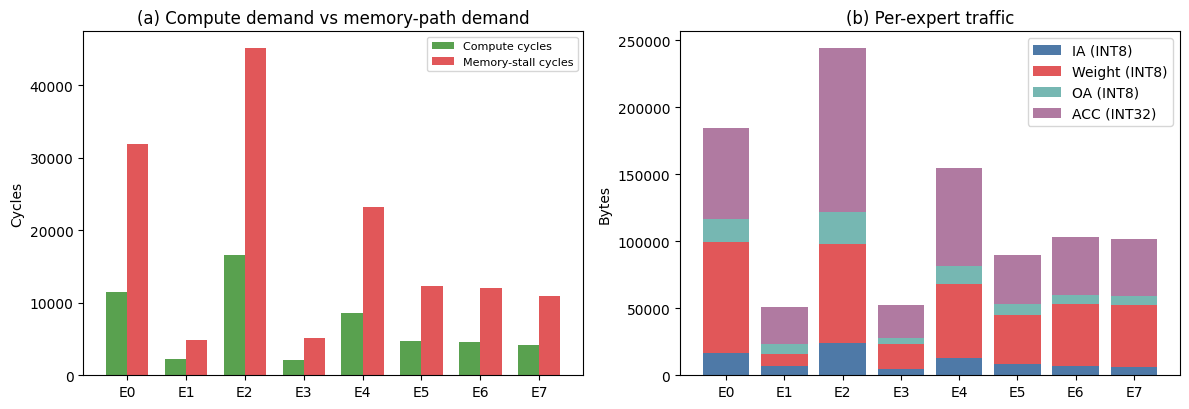

,expert_id,tokens,compute_cycles,critical_bank_service_cycles,memory_stall_cycles,total_cycles,ia_bytes,weight_bytes,accumulator_bytes,oa_bytes,memory_to_compute_ratio
0,0,64,11556,9664,31848,43404,16896,82944,67584,16896,2.755971
1,1,96,2214,1440,4860,7074,6912,9216,27648,6912,2.195122
2,2,100,16560,13400,45198,61758,24000,73728,122880,24000,2.729348
3,3,48,2160,1536,5112,7272,4608,18432,24576,4608,2.366667
4,4,68,8640,6800,23208,31848,13056,55296,73728,13056,2.686111
5,5,56,4680,3696,12366,17046,8064,36864,36864,8064,2.642308
6,6,42,4536,3486,12003,16539,7056,46080,43008,7056,2.646164
7,7,38,4176,3154,11007,15183,6384,46080,43008,6384,2.635776


Experts with exposed memory stall above compute: 8 / 8


In [57]:
expert=df[df.category=='MoE Expert'].copy()
expert['expert_id']=expert.layer.str.extract(r'E(\d+)').astype(int)
expert_summary=expert.groupby('expert_id').agg(
    tokens=('M','sum'),
    compute_cycles=('compute_cycles','sum'),
    critical_bank_service_cycles=('critical_bank_service_cycles','sum'),
    memory_stall_cycles=('memory_stall_cycles','sum'),
    total_cycles=('total_cycles','sum'),
    ia_bytes=('ia_bytes','sum'),
    weight_bytes=('weight_bytes','sum'),
    accumulator_bytes=('accumulator_bytes','sum'),
    oa_bytes=('oa_bytes','sum')).reset_index()
expert_summary['memory_to_compute_ratio']=expert_summary.memory_stall_cycles/expert_summary.compute_cycles
expert_summary.to_csv(FIG/'exp1_expert_summary.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4.2)); x=np.arange(len(expert_summary))
width=.36
axes[0].bar(x-width/2,expert_summary.compute_cycles,width,color='#59A14F',label='Compute cycles')
axes[0].bar(x+width/2,expert_summary.memory_stall_cycles,width,color='#E15759',label='Memory-stall cycles')
axes[0].set_xticks(x,[f'E{i}' for i in expert_summary.expert_id]);axes[0].set_ylabel('Cycles')
axes[0].set_title('(a) Compute demand vs memory-path demand');axes[0].legend(fontsize=8)
bottom=np.zeros(len(expert_summary))
for col,label,color in [('ia_bytes','IA (INT8)','#4E79A7'),('weight_bytes','Weight (INT8)','#E15759'),
                        ('oa_bytes','OA (INT8)','#76B7B2'),('accumulator_bytes','ACC (INT32)','#B07AA1')]:
    axes[1].bar(x,expert_summary[col],bottom=bottom,label=label,color=color)
    bottom+=expert_summary[col].to_numpy()
axes[1].set_xticks(x,[f'E{i}' for i in expert_summary.expert_id]);axes[1].set_ylabel('Bytes');axes[1].set_title('(b) Per-expert traffic');axes[1].legend()
plt.tight_layout();plt.savefig(FIG/'exp1_expert_heterogeneity.pdf',bbox_inches='tight');plt.show()
display(expert_summary)
print('Experts with exposed memory stall above compute:',
      int((expert_summary.memory_to_compute_ratio>1).sum()),'/',len(expert_summary))


红柱高于绿柱表示该专家实际暴露的访存等待超过计算。右图同时计入INT8
IA/Weight/OA和Banked INT32 ACC流量。


## 4.1 Tile级Working Set与Active Bank Demand


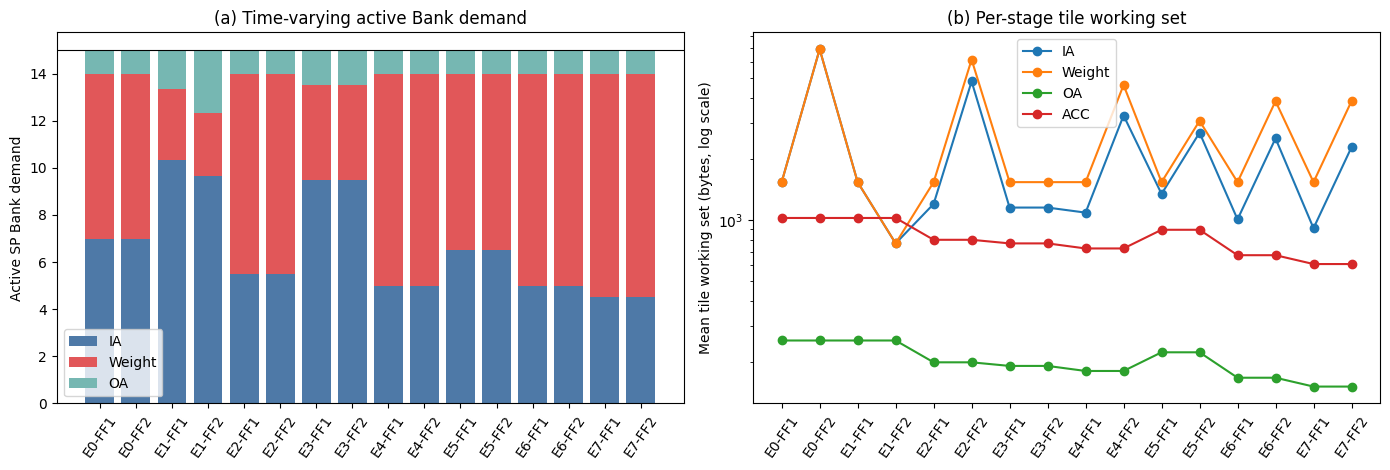

Tile records: 973 unique active SP ratios: 12


,layer,tile_index,ia_working_set_bytes,weight_working_set_bytes,oa_working_set_bytes,accumulator_working_set_bytes,active_ia_banks,active_weight_banks,active_oa_banks
544,MoE-E0-FF1,0,1536,1536,256,1024,7,7,1
545,MoE-E0-FF1,1,1536,1536,256,1024,7,7,1
546,MoE-E0-FF1,2,1536,1536,256,1024,7,7,1
547,MoE-E0-FF1,3,1536,1536,256,1024,7,7,1
548,MoE-E0-FF1,4,1536,1536,256,1024,7,7,1
549,MoE-E0-FF1,5,1536,1536,256,1024,7,7,1
550,MoE-E0-FF1,6,1536,1536,256,1024,7,7,1
551,MoE-E0-FF1,7,1536,1536,256,1024,7,7,1
552,MoE-E0-FF1,8,1536,1536,256,1024,7,7,1
553,MoE-E0-FF1,9,1536,1536,256,1024,7,7,1


In [58]:
expert_tiles=temporal[temporal.layer_type.str.startswith('Expert')].copy()
expert_tiles['stage']=expert_tiles.layer.str.extract(r'(E\d+-FF[12])')
bank_cols=['active_ia_banks','active_weight_banks','active_oa_banks']
working_cols=['ia_working_set_bytes','weight_working_set_bytes',
              'oa_working_set_bytes','accumulator_working_set_bytes']
fig,axes=plt.subplots(1,2,figsize=(14,4.8))
p=expert_tiles.groupby('stage')[bank_cols].mean()
bottom=np.zeros(len(p))
for col,label,color in zip(bank_cols,['IA','Weight','OA'],['#4E79A7','#E15759','#76B7B2']):
    axes[0].bar(p.index,p[col],bottom=bottom,label=label,color=color)
    bottom+=p[col].to_numpy()
axes[0].axhline(15,color='black',lw=.8);axes[0].set_ylabel('Active SP Bank demand')
axes[0].set_title('(a) Time-varying active Bank demand');axes[0].tick_params(axis='x',rotation=55);axes[0].legend()
w=expert_tiles.groupby('stage')[working_cols].mean()
for col,label in zip(working_cols,['IA','Weight','OA','ACC']):
    axes[1].plot(w.index,w[col],marker='o',label=label)
axes[1].set_yscale('log');axes[1].set_ylabel('Mean tile working set (bytes, log scale)')
axes[1].set_title('(b) Per-stage tile working set');axes[1].tick_params(axis='x',rotation=55);axes[1].legend()
plt.tight_layout();plt.savefig(FIG/'exp1_temporal_tile_demand.pdf',bbox_inches='tight');plt.show()
print('Tile records:',len(temporal),'unique active SP ratios:',
      temporal[bank_cols].drop_duplicates().shape[0])
display(expert_tiles[['layer','tile_index',*working_cols,*bank_cols]].head(12))


## 5. IA/Weight/OA 时变需求与理想 Bank 比例


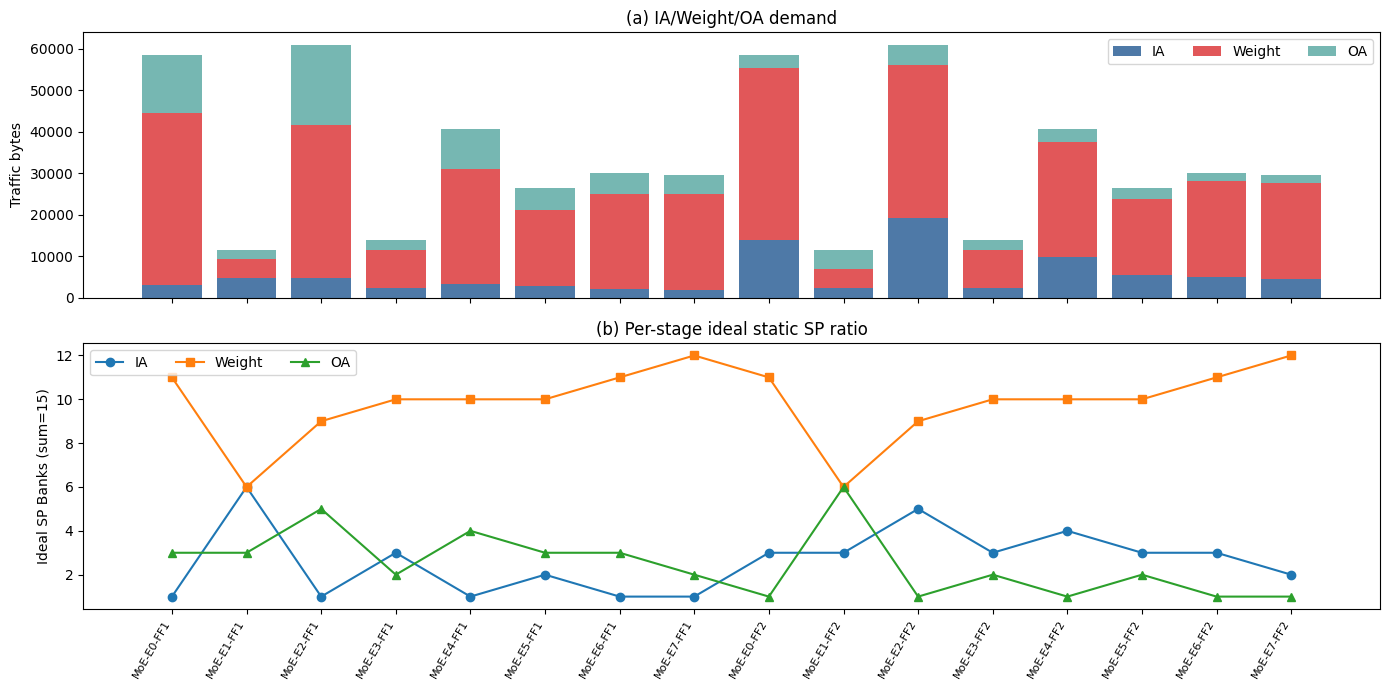

,layer,ia_bytes,weight_bytes,oa_bytes,ideal_ia_banks,ideal_weight_banks,ideal_oa_banks
0,MoE-E0-FF1,3072,41472,13824,1,11,3
1,MoE-E1-FF1,4608,4608,2304,6,6,3
2,MoE-E2-FF1,4800,36864,19200,1,9,5
3,MoE-E3-FF1,2304,9216,2304,3,10,2
4,MoE-E4-FF1,3264,27648,9792,1,10,4
5,MoE-E5-FF1,2688,18432,5376,2,10,3
6,MoE-E6-FF1,2016,23040,5040,1,11,3
7,MoE-E7-FF1,1824,23040,4560,1,12,2
8,MoE-E0-FF2,13824,41472,3072,3,11,1
9,MoE-E1-FF2,2304,4608,4608,3,6,6


In [59]:
stage=df[df.category=='MoE Expert'].sort_values(['layer_type','layer']).reset_index(drop=True)
fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True);x=np.arange(len(stage))
bottom=np.zeros(len(stage))
for col,label,color in [('ia_bytes','IA','#4E79A7'),('weight_bytes','Weight','#E15759'),('oa_bytes','OA','#76B7B2')]: axes[0].bar(x,stage[col],bottom=bottom,label=label,color=color);bottom+=stage[col].to_numpy()
axes[0].set_ylabel('Traffic bytes');axes[0].set_title('(a) IA/Weight/OA demand');axes[0].legend(ncol=3)
axes[1].plot(x,stage.ideal_ia_banks,marker='o',label='IA');axes[1].plot(x,stage.ideal_weight_banks,marker='s',label='Weight');axes[1].plot(x,stage.ideal_oa_banks,marker='^',label='OA');axes[1].set_ylabel('Ideal SP Banks (sum=15)');axes[1].set_xticks(x,stage.layer,rotation=60,ha='right',fontsize=8);axes[1].set_title('(b) Per-stage ideal static SP ratio');axes[1].legend(ncol=3)
plt.tight_layout();plt.savefig(FIG/'exp1_flow_and_ideal_banks.pdf',bbox_inches='tight');plt.show()
stage[['layer','ia_bytes','weight_bytes','oa_bytes','ideal_ia_banks','ideal_weight_banks','ideal_oa_banks']]


不存在一组固定 IA:Weight:OA 比例对所有专家和阶段同时最优，这直接支持 C1 的“需求独立变化与静态比例失配”结论。

## 实验 1 最终判断

- **B1判断**：用MoE的stall占比、compute占比、平均每层stall和stall-ratio差值共同判断访存优化空间，避免把“stall必须超过compute”作为错误门槛。
- **C1判断**：专家异构；IA/Weight/OA独立变化；理想Bank比例随专家及FF1/FF2改变，说明固定5:5:5所有权无法持续匹配时变流量。
- **精度契约**：原始模型FP32；片上IA/Weight/OA为INT8；跨K-tile部分和采用banked INT32 RMW。
- **写论文时应避免**：把请求内部串行造成的high conflict rate当成唯一根因，或引用旧的local/spill ACC敏感性CSV替代当前主模型。
